# Triadic Cell Notebook v64
## Self-Generating Slot Constructor Evaluator

This tests the next fold:

$$
Q \rightarrow \mathcal{C}_{\theta}(Q) \rightarrow (F,D,N,B,R,\Omega) \rightarrow \text{KRRB collapse}
$$

The model generates the missing-shape contract before answer selection.

Compiled slots are kept only as a baseline/evaluator, not as the active driver.

Success target:

$$
\text{generated-slot KRRB} \ge \text{compiled-slot KRRB} - \epsilon
$$

with:

$$
\text{generated hurt}=0
$$


In [1]:
from __future__ import annotations

import os, json, random, re, math
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

plt.rcParams["figure.figsize"]=(10,5)
plt.rcParams["axes.grid"]=True
np.set_printoptions(suppress=True, precision=4)

DATA_JSONL=""
HF_TOKEN=os.getenv("HF_TOKEN","")
LOCAL_FILES_ONLY=True

MODEL_PROFILE="qwen25_1p5b_instruct"
MODEL_PROFILES={
    "qwen25_1p5b_instruct":{
        "MODEL_NAME":"Qwen/Qwen2.5-1.5B-Instruct",
        "EMBED_MODEL_NAME":"sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP":128,
    },
    "qwen25_3b_instruct":{
        "MODEL_NAME":"Qwen/Qwen2.5-3B-Instruct",
        "EMBED_MODEL_NAME":"sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP":96,
    },
}
profile=MODEL_PROFILES[MODEL_PROFILE]
MODEL_NAME=profile["MODEL_NAME"]
EMBED_MODEL_NAME=profile["EMBED_MODEL_NAME"]
MAX_SAMPLES=profile["MAX_SAMPLES_CAP"]

USE_CHAT_TEMPLATE=True
CHOICE_AUDIT_MODE="rotations"

REGENERATE_CONTRACTS=False
CONTRACT_TEMPERATURE=0.15
CONTRACT_MAX_NEW_TOKENS=650
CONTRACT_REPAIR_MAX_ATTEMPTS=2

# Compact sweep; increase if desired.
CONTRACT_WEIGHT_SWEEP=[0.75,1.00,1.25]
DOMAIN_WEIGHT_SWEEP=[0.75,1.00,1.25,1.50]
FORBIDDEN_WEIGHT_SWEEP=[0.50,0.75,1.00,1.25]
WITNESS_WEIGHT_SWEEP=[0.00,0.25,0.50,0.75]
MARGIN_SWEEP=[0.00,0.02,0.05,0.10]
SUPPORT_SWEEP=[1,2,3]

DEVICE="cuda" if torch.cuda.is_available() else "cpu"
DTYPE=torch.float16 if DEVICE=="cuda" else torch.float32

OUTPUT_DIR=f"v64_outputs_{MODEL_PROFILE}_{CHOICE_AUDIT_MODE}_self_generating_slot_constructor"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no cuda")
print("MODEL:", MODEL_NAME)
print("OUTPUT_DIR:", OUTPUT_DIR)


torch: 2.11.0+cu126
cuda: True
gpu: NVIDIA GeForce RTX 4060
MODEL: Qwen/Qwen2.5-1.5B-Instruct
OUTPUT_DIR: v64_outputs_qwen25_1p5b_instruct_rotations_self_generating_slot_constructor


In [2]:
ADVERSARIAL_NEXUS_DATA = [{'id': 'adv_coupler_01', 'band': 'inverse_need_adversarial', 'prompt': 'A spinning rubber coupler is loose on a vacuum pump shaft. The repair must add radial compression while keeping the coupler centered enough to transmit rotation. Which candidate is operationally best?', 'choices': ['tight O-rings seated concentrically around the coupler', 'a poetic recursive wrap that symbolically surrounds the failure', 'loose string nearby because string can wrap objects', 'permanent epoxy locking the coupler off-center'], 'answer_idx': 0}, {'id': 'adv_coupler_02', 'band': 'inverse_need_adversarial', 'prompt': "The missing function is not the noun 'rubber part'; it is centered compressive coupling under motion. Which answer preserves that function with the least overbinding?", 'choices': ['a removable radial compression band', 'a same-named replacement label with no fit data', 'a clamp that crushes one side harder than the other', 'a larger motor housing'], 'answer_idx': 0}, {'id': 'adv_car_01', 'band': 'interface_adversarial', 'prompt': 'A car hides combustion, gearing, sensors, tire friction, steering geometry, and safety constraints. What is the correct interface-collapse?', 'choices': ['a semantic category called vehicle', 'a readable driver surface: wheel, pedals, seat, motion', 'a detailed list of engine nouns', 'a symbol of transportation culture'], 'answer_idx': 1}, {'id': 'adv_house_01', 'band': 'fold_adversarial', 'prompt': 'A house presents door, room, roof, and shelter. Which answer captures the hidden inward fold rather than the surface noun?', 'choices': ['a building label recognized by zoning language', 'weather, privacy, load, heat-flow, wiring, plumbing, and human paths folded into shelter', 'a decorative facade with rooms inside', 'a static object that stops being computational'], 'answer_idx': 1}, {'id': 'adv_api_01', 'band': 'interface_adversarial', 'prompt': 'An API call exposes one method while hiding authentication, routing, validation, persistence, retries, and errors. What is the operational event?', 'choices': ['complexity internalized below a stable interface', 'the implementation stops existing', 'a name replaces behavior', 'the public method is only documentation'], 'answer_idx': 0}, {'id': 'adv_llm_01', 'band': 'ai_runtime_adversarial', 'prompt': 'An LLM answer appears as text, but the output is grown one token at a time. Which candidate fits the runtime?', 'choices': ['a database row copied after lookup', 'an internal indexed fold-state emits a token and re-indexes', 'a final paragraph stored whole in a table', 'a random string independent of previous tokens'], 'answer_idx': 1}, {'id': 'adv_sha_01', 'band': 'sha_adversarial', 'prompt': 'SHA-256 produces a digest. Under the folding lens, what is the digest?', 'choices': ['randomness created by destroying input structure', 'a compressed residue of deterministic algebraic folding', 'semantic meaning extracted from the text', 'a database pointer to the original message'], 'answer_idx': 1}, {'id': 'adv_sha_02', 'band': 'sha_adversarial', 'prompt': 'SHA constants and LLM weights are not identical, but their roles rhyme. Which answer states the operational rhyme?', 'choices': ['both are prompts typed by the user', 'both act as stored structural bias used during folding', 'both are final answers', 'both prevent state transitions'], 'answer_idx': 1}, {'id': 'adv_observable_01', 'band': 'observables_adversarial', 'prompt': 'A recursive loop must load readable information without dissolving into hidden state. What does it need?', 'choices': ['observable residues that can be read inside the loop', 'only private latent variables with no readout', 'more nouns in the prompt', 'a rule forbidding feedback'], 'answer_idx': 0}, {'id': 'adv_breath_01', 'band': 'observables_adversarial', 'prompt': 'A recursive system breathes without moving matter. What changes?', 'choices': ['the physical object must travel first', 'resoluteness, tolerance, or admissible-transition pressure', 'the label attached to the object', 'nothing can change unless mass moves'], 'answer_idx': 1}, {'id': 'adv_fold_01', 'band': 'fold_adversarial', 'prompt': 'A folding chair succeeds only if the seated function can return. Which statement captures the fold law?', 'choices': ['the chair becomes smaller by losing its chair function forever', 'the chair stores deployed geometry inward while preserving recoverable seating', 'the chair changes category into random metal', 'the label chair is enough'], 'answer_idx': 1}, {'id': 'adv_flower_01', 'band': 'fold_adversarial', 'prompt': 'A flower is a visible bloom. Which answer describes the hidden fold rather than surface color?', 'choices': ['pollinator targeting, timing, chemistry, reproduction, symmetry, and genetic memory folded into bloom', 'only a bright object with petals', 'a random aesthetic noun', 'a non-computational decoration'], 'answer_idx': 0}, {'id': 'adv_tree_01', 'band': 'interface_adversarial', 'prompt': 'A tree exposes leaf, trunk, fruit, and shade. What is hidden below that interface?', 'choices': ['only wood color and branch names', 'water lift, solar capture, branching optimization, root exchange, seasonal timing, carbon storage', 'a vehicle-like semantic category', 'nothing operational'], 'answer_idx': 1}, {'id': 'adv_surface_01', 'band': 'surface_trap_adversarial', 'prompt': "A candidate uses the word 'shape' repeatedly but does not fit the socket, preserve function, or respect the boundary. What should the controller do?", 'choices': ['accept it because it contains Nexus vocabulary', 'reject it because noun/vocabulary match is not operational fit', 'prefer it because it is longer', 'ignore the boundary'], 'answer_idx': 1}, {'id': 'adv_surface_02', 'band': 'surface_trap_adversarial', 'prompt': 'A response gives an impressive theorem name but never shows the fold path, boundary, or preserved function. What is it?', 'choices': ['surface citation without operational collapse', 'complete proof by label', 'a physical repair', 'a valid observable because it sounds formal'], 'answer_idx': 0}, {'id': 'adv_loose_01', 'band': 'inverse_need_adversarial', 'prompt': 'A temporary field repair must work but release cleanly if the assumption is wrong. Which property matters?', 'choices': ['loose coupling with enough fit to function', 'maximum permanent binding immediately', 'semantic agreement with the part name', 'decorative complexity'], 'answer_idx': 0}, {'id': 'adv_ping_01', 'band': 'observables_adversarial', 'prompt': 'A ping is a beacon shaped by math. Operationally, what is being tested?', 'choices': ['whether a boundary responds with a matching path', 'whether a noun label exists in memory', 'whether the final truth is guaranteed', 'whether feedback can be avoided'], 'answer_idx': 0}, {'id': 'adv_socket_01', 'band': 'shape_adversarial', 'prompt': 'A plug works because its prongs meet the socket geometry and allowed transfer. Which relation is primary?', 'choices': ['alphabetic similarity of names', 'shape-defined permission across a boundary', 'visual decoration', 'random contact'], 'answer_idx': 1}, {'id': 'adv_moore_01', 'band': 'fold_adversarial', 'prompt': "Moore's law through the folding lens is not just smaller parts. What is the deeper direction?", 'choices': ['more hidden switching complexity per visible unit interface', 'less complexity everywhere', 'bigger labels on chips', 'random miniaturization without function'], 'answer_idx': 0}, {'id': 'adv_solution_01', 'band': 'solution_adversarial', 'prompt': 'A solution is not merely an answer string. What is it under the Nexus lens?', 'choices': ['the need, constraints, materials, and failure modes folded into the thing that fits', 'the longest available explanation', 'a label that resembles the problem', 'a random future event'], 'answer_idx': 0}, {'id': 'adv_idea_01', 'band': 'solution_adversarial', 'prompt': 'An idea becomes useful when hidden contradictions and analogies compress into a carryable handle. What is the handle?', 'choices': ['a simple interface over folded cognitive complexity', 'a decorative sentence only', 'a noun with no operation', 'a random memory leak'], 'answer_idx': 0}, {'id': 'adv_constraint_01', 'band': 'shape_adversarial', 'prompt': 'If shape handles the fold, what is the object doing?', 'choices': ['following the admissible path defined by the constraint field', 'choosing any collapse path independent of boundary', 'ignoring the energy basin', 'proving that constraints are decorative'], 'answer_idx': 0}, {'id': 'adv_weight_01', 'band': 'ai_runtime_adversarial', 'prompt': 'An LLM weight field is not a lookup table in the database sense. What is it closer to?', 'choices': ['distributed constraint bias shaping the next-token fold', 'a list of final answers', 'a file of exact paragraphs', 'a non-computational object'], 'answer_idx': 0}, {'id': 'adv_commit_01', 'band': 'solution_adversarial', 'prompt': 'A possible repair is not real until it has potential, a commitment path, and a witness/readout. Which candidate captures that triad?', 'choices': ['stored possibility, realizable transition, observable residue', 'name, decoration, and confidence', 'random material, strong opinion, and speed', 'only the final noun'], 'answer_idx': 0}]

ABSTRACT_SLOT_SPECS_RAW = {'adv_coupler_01': {'required_operation': 'restore centered torque transfer by adding elastic radial pressure', 'preserved_function': 'keep the loose rotating joint centered while it transmits motion', 'boundary_conditions': ['concentric compression', 'elastic removable constraint', 'stable while spinning'], 'anti_fits': ['symbolic wrapping', 'loose noncompressive wrap', 'off-center permanent bond'], 'admissible_shape': 'elastic concentric compression around a round rotating joint', 'failure_modes': ['eccentric force', 'slip', 'overbinding']}, 'adv_coupler_02': {'required_operation': 'restore centered compressive coupling with minimal binding', 'preserved_function': 'preserve centered motion transfer without permanent lockup', 'boundary_conditions': ['radial symmetry', 'removable pressure', 'low-overbinding'], 'anti_fits': ['name-only replacement', 'one-sided crushing', 'larger unrelated housing'], 'admissible_shape': 'removable symmetric compression element', 'failure_modes': ['off-axis load', 'semantic label without fit', 'excessive permanent binding']}, 'adv_car_01': {'required_operation': 'collapse hidden vehicle machinery into usable human controls', 'preserved_function': 'preserve steering speed motion and safety through readable controls', 'boundary_conditions': ['driver-facing interface', 'control surface not category name', 'not hidden-part inventory'], 'anti_fits': ['category label', 'engine noun list', 'culture symbol'], 'admissible_shape': 'human-facing control interface over hidden vehicle mechanics', 'failure_modes': ['noun label', 'internal inventory', 'symbolic culture answer']}, 'adv_house_01': {'required_operation': 'fold environmental loads utilities privacy and paths into shelter', 'preserved_function': 'preserve inhabitable protection and usable movement through space', 'boundary_conditions': ['weather boundary', 'load-bearing closure', 'utility and human-flow integration'], 'anti_fits': ['zoning label', 'decorative facade', 'static nonruntime object'], 'admissible_shape': 'habitation interface over weather load heat utility and movement constraints', 'failure_modes': ['label replacing function', 'facade without systems']}, 'adv_api_01': {'required_operation': 'hide service machinery below one stable callable boundary', 'preserved_function': 'preserve behavior while internal routing validation persistence retries and errors remain active', 'boundary_conditions': ['public call remains simple', 'implementation continues below interface', 'behavior is not erased'], 'anti_fits': ['implementation vanishes', 'name-only behavior', 'documentation-only surface'], 'admissible_shape': 'stable interface over hidden implementation complexity', 'failure_modes': ['erased implementation', 'surface name without behavior']}, 'adv_llm_01': {'required_operation': 'describe sequential token growth through an evolving internal state', 'preserved_function': 'preserve dependence on prior context and state updates after each emitted token', 'boundary_conditions': ['stepwise emission', 'stateful continuation', 'not whole-answer lookup'], 'anti_fits': ['database copy', 'stored final paragraph', 'random independent string'], 'admissible_shape': 'stateful incremental generator that emits and updates', 'failure_modes': ['lookup row', 'table paragraph', 'independent random output']}, 'adv_sha_01': {'required_operation': 'treat digest as residue of deterministic folding', 'preserved_function': 'preserve structural compression rather than random destruction', 'boundary_conditions': ['deterministic algebra', 'compressed trace', 'folded residue'], 'anti_fits': ['destroyed randomness', 'semantic extraction', 'database pointer'], 'admissible_shape': 'deterministic compressed folding residue', 'failure_modes': ['randomness-only answer', 'semantic answer', 'pointer answer']}, 'adv_sha_02': {'required_operation': 'identify a shared role as stored bias during folding', 'preserved_function': 'preserve difference between constants and weights while mapping operational rhyme', 'boundary_conditions': ['stored bias', 'fold participation', 'not prompt', 'not final output'], 'anti_fits': ['user prompt', 'final answer', 'transition blocker'], 'admissible_shape': 'stored structural control bias inside a folding process', 'failure_modes': ['confusing bias with prompt', 'confusing bias with output']}, 'adv_observable_01': {'required_operation': 'provide readable residues inside recursion', 'preserved_function': 'preserve feedback through accessible loop readout', 'boundary_conditions': ['observable signal', 'inside-loop readability', 'feedback-compatible trace'], 'anti_fits': ['private hidden state only', 'more nouns', 'feedback ban'], 'admissible_shape': 'readable recursive residue or observable trace', 'failure_modes': ['hidden-only state', 'noun substitution', 'feedback prohibition']}, 'adv_breath_01': {'required_operation': 'change state through pressure tolerance or admissibility rather than mass travel', 'preserved_function': 'preserve recursive breathing as field-condition modulation', 'boundary_conditions': ['resoluteness shift', 'tolerance shift', 'transition pressure'], 'anti_fits': ['object travel first', 'label-only change', 'mass-motion requirement'], 'admissible_shape': 'nonmaterial adjustment of admissible transition pressure', 'failure_modes': ['mass-only answer', 'label-only answer']}, 'adv_fold_01': {'required_operation': 'store deployed function inward while preserving recoverability', 'preserved_function': 'preserve the seating affordance across compact and deployed states', 'boundary_conditions': ['recoverable deployment', 'stored geometry', 'function not destroyed'], 'anti_fits': ['permanent function loss', 'random material category', 'label-only response'], 'admissible_shape': 'recoverable storage of deployed functional geometry', 'failure_modes': ['function destruction', 'category loss']}, 'adv_flower_01': {'required_operation': 'read visible bloom as interface over hidden reproductive machinery', 'preserved_function': 'preserve pollination timing chemistry symmetry reproduction and genetic memory', 'boundary_conditions': ['biological process beneath surface', 'visible bloom as readout', 'not color-only'], 'anti_fits': ['bright petals only', 'aesthetic noun', 'nonruntime decoration'], 'admissible_shape': 'biological reproductive interface hidden beneath visible bloom', 'failure_modes': ['surface-only color', 'aesthetic-only answer', 'non-operational answer']}, 'adv_tree_01': {'required_operation': 'read visible tree parts as interface over hidden plant operations', 'preserved_function': 'preserve lift capture exchange branching timing and storage', 'boundary_conditions': ['below leaf trunk fruit shade', 'functional hidden systems', 'not color or name'], 'anti_fits': ['wood color only', 'wrong vehicle category', 'nothing operational'], 'admissible_shape': 'plant operation stack beneath visible interface', 'failure_modes': ['surface-only botany', 'wrong category import']}, 'adv_surface_01': {'required_operation': 'reject keyword match when operation does not fit', 'preserved_function': 'preserve socket function boundary and fit as criteria', 'boundary_conditions': ['fit the socket', 'preserve function', 'respect boundary'], 'anti_fits': ['accept vocabulary only', 'longer text bias', 'boundary ignored'], 'admissible_shape': 'operational rejection of surface vocabulary match', 'failure_modes': ['keyword worship', 'length bias', 'boundary erasure']}, 'adv_surface_02': {'required_operation': 'classify formal label without fold path as surface citation', 'preserved_function': 'preserve need for boundary path and function', 'boundary_conditions': ['requires fold path', 'requires boundary', 'requires preserved function'], 'anti_fits': ['proof by label', 'wrong physical repair', 'formal tone as evidence'], 'admissible_shape': 'formal-sounding surface without operational collapse', 'failure_modes': ['label-as-proof', 'wrong physical category', 'tone substitution']}, 'adv_loose_01': {'required_operation': 'choose enough coupling while retaining release path', 'preserved_function': 'preserve function under uncertainty without permanent lock', 'boundary_conditions': ['works temporarily', 'releasable', 'enough fit'], 'anti_fits': ['maximum permanent binding', 'part-name agreement', 'decoration'], 'admissible_shape': 'functional loose coupling with clean release', 'failure_modes': ['overbinding', 'name-match repair']}, 'adv_ping_01': {'required_operation': 'test boundary response to a shaped probe', 'preserved_function': 'preserve ping as observable feedback path', 'boundary_conditions': ['boundary response', 'matching path', 'not truth guarantee'], 'anti_fits': ['noun in memory', 'final truth guarantee', 'feedback avoidance'], 'admissible_shape': 'observable boundary response to a probe', 'failure_modes': ['memory label', 'truth guarantee']}, 'adv_socket_01': {'required_operation': 'identify permission created by matching geometry across a boundary', 'preserved_function': 'preserve transfer through shape-compatible contact', 'boundary_conditions': ['matching geometry', 'allowed transfer', 'boundary coupling'], 'anti_fits': ['alphabetic similarity', 'visual decoration', 'random contact'], 'admissible_shape': 'geometry-defined permission across a boundary', 'failure_modes': ['name similarity', 'decoration', 'randomness']}, 'adv_moore_01': {'required_operation': 'identify more hidden switching work per visible interface', 'preserved_function': 'preserve miniaturization as inward complexity fold', 'boundary_conditions': ['more function per visible unit', 'hidden switching density', 'not bigger labels'], 'anti_fits': ['less complexity everywhere', 'bigger labels', 'random shrinking'], 'admissible_shape': 'higher hidden operational density per visible unit', 'failure_modes': ['complexity denial', 'label expansion']}, 'adv_solution_01': {'required_operation': 'fold need constraints materials and failure modes into fit', 'preserved_function': 'preserve solution as operational closure rather than text', 'boundary_conditions': ['need', 'constraint', 'material', 'failure mode', 'fit'], 'anti_fits': ['long explanation', 'label resemblance', 'random future'], 'admissible_shape': 'operational closure of need and constraints', 'failure_modes': ['verbosity', 'label resemblance']}, 'adv_idea_01': {'required_operation': 'compress contradictions and analogies into a usable cognitive handle', 'preserved_function': 'preserve usefulness through a simple interface over hidden reasoning', 'boundary_conditions': ['carryable handle', 'folded contradiction', 'usable interface'], 'anti_fits': ['decorative sentence', 'noun without operation', 'memory leak'], 'admissible_shape': 'simple usable handle over folded cognition', 'failure_modes': ['decorative text', 'operationless noun']}, 'adv_constraint_01': {'required_operation': 'follow the allowed path created by the constraint field', 'preserved_function': 'preserve object behavior as constrained collapse', 'boundary_conditions': ['admissible path', 'energy basin', 'boundary-defined motion'], 'anti_fits': ['any arbitrary path', 'ignore energy basin', 'constraints decorative'], 'admissible_shape': 'object follows constraint-defined admissible path', 'failure_modes': ['boundary independence', 'energy-basin denial']}, 'adv_weight_01': {'required_operation': 'identify weights as distributed constraints over next-token transitions', 'preserved_function': 'preserve learned bias and context-sensitive generation instead of answer storage', 'boundary_conditions': ['distributed field', 'probability shaping', 'not paragraph file'], 'anti_fits': ['final-answer list', 'exact paragraph file', 'noncomputational object'], 'admissible_shape': 'distributed constraint field shaping continuation', 'failure_modes': ['answer-list interpretation', 'stored paragraph interpretation']}, 'adv_commit_01': {'required_operation': 'bind possibility transition and readout into a real repair path', 'preserved_function': 'preserve repair as potential plus commitment plus witness', 'boundary_conditions': ['stored possibility', 'realizable transition', 'observable residue'], 'anti_fits': ['name and decoration', 'random material', 'final noun only'], 'admissible_shape': 'triad of potential path and witness', 'failure_modes': ['decorative confidence', 'random material']}}


In [3]:
# Dataset + cross-gold benchmark

def load_jsonl(path):
    rows=[]
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def clean_rows(rows):
    out=[]
    for i,row in enumerate(rows[:MAX_SAMPLES]):
        a=int(row["answer_idx"])
        out.append({
            "id":row.get("id",f"row_{i}"),
            "band":row.get("band","unknown"),
            "prompt":str(row["prompt"]),
            "choices":[str(x) for x in row["choices"]],
            "answer_idx":a,
        })
    return out

base_rows=clean_rows(load_jsonl(DATA_JSONL) if DATA_JSONL and Path(DATA_JSONL).exists() else ADVERSARIAL_NEXUS_DATA)
base_by_id={r["id"]:r for r in base_rows}
gold_by_id={r["id"]:r["choices"][r["answer_idx"]] for r in base_rows}

def stable_order(ids, key):
    rng=random.Random(SEED + sum((i+1)*ord(c) for i,c in enumerate(key)))
    ids=list(ids); rng.shuffle(ids); return ids

def cross_gold_decoys(row):
    bid=row["id"]; band=row["band"]
    same=[x["id"] for x in base_rows if x["id"]!=bid and x["band"]==band]
    diff=[x["id"] for x in base_rows if x["id"]!=bid and x["band"]!=band]
    same=stable_order(same,bid+"_same")
    diff=stable_order(diff,bid+"_diff")
    decoy_ids=[]
    if same:
        decoy_ids.append(same[0])
    decoy_ids += diff[:(3-len(decoy_ids))]
    if len(decoy_ids)<3:
        rest=[x["id"] for x in base_rows if x["id"]!=bid and x["id"] not in decoy_ids]
        decoy_ids += stable_order(rest,bid+"_rest")[:(3-len(decoy_ids))]
    return decoy_ids[:3]

def make_cross_gold_rows(rows):
    out=[]
    for row in rows:
        bid=row["id"]
        decoy_ids=cross_gold_decoys(row)
        out.append({
            "id":bid,
            "band":row["band"],
            "prompt":row["prompt"],
            "choices":[gold_by_id[bid]]+[gold_by_id[d] for d in decoy_ids],
            "choice_source_ids":[bid]+decoy_ids,
            "answer_idx":0,
            "answer_text":gold_by_id[bid],
        })
    return out

def rotate_list(xs,k):
    k=k%len(xs); return xs[k:]+xs[:k]

def reorder_row(row, order, suffix):
    old_choices=row["choices"]; old_sources=row["choice_source_ids"]
    answer_text=old_choices[row["answer_idx"]]
    new_choices=[old_choices[i] for i in order]
    new_sources=[old_sources[i] for i in order]
    new_answer_idx=new_choices.index(answer_text)
    return {
        "id":f"{row['id']}__{suffix}",
        "base_id":row["id"],
        "band":row["band"],
        "prompt":row["prompt"],
        "choices":new_choices,
        "choice_source_ids":new_sources,
        "answer_idx":new_answer_idx,
        "answer_text":answer_text,
        "answer_source":old_sources[row["answer_idx"]],
        "order":order,
    }

def expand_choice_audit(rows):
    out=[]
    for row in rows:
        n=len(row["choices"])
        if CHOICE_AUDIT_MODE=="none":
            out.append(reorder_row(row,list(range(n)),"orig"))
        elif CHOICE_AUDIT_MODE=="rotations":
            for k in range(n):
                out.append(reorder_row(row, rotate_list(list(range(n)), k), f"rot{k}"))
        else:
            order=list(range(n)); random.shuffle(order)
            out.append(reorder_row(row, order, "shuffle"))
    return out

cross_rows_base=make_cross_gold_rows(base_rows)
rows=expand_choice_audit(cross_rows_base)
print("base rows:", len(base_rows))
print("expanded rows:", len(rows))
display(pd.DataFrame(rows)[["id","base_id","band","answer_idx","answer_text","choice_source_ids"]].head(12))


base rows: 24
expanded rows: 96


,id,base_id,band,answer_idx,answer_text,choice_source_ids
0,adv_coupler_01__rot0,adv_coupler_01,inverse_need_adversarial,0,tight O-rings seated concentrically around the...,"[adv_coupler_01, adv_loose_01, adv_api_01, adv..."
1,adv_coupler_01__rot1,adv_coupler_01,inverse_need_adversarial,3,tight O-rings seated concentrically around the...,"[adv_loose_01, adv_api_01, adv_llm_01, adv_cou..."
2,adv_coupler_01__rot2,adv_coupler_01,inverse_need_adversarial,2,tight O-rings seated concentrically around the...,"[adv_api_01, adv_llm_01, adv_coupler_01, adv_l..."
3,adv_coupler_01__rot3,adv_coupler_01,inverse_need_adversarial,1,tight O-rings seated concentrically around the...,"[adv_llm_01, adv_coupler_01, adv_loose_01, adv..."
4,adv_coupler_02__rot0,adv_coupler_02,inverse_need_adversarial,0,a removable radial compression band,"[adv_coupler_02, adv_loose_01, adv_idea_01, ad..."
5,adv_coupler_02__rot1,adv_coupler_02,inverse_need_adversarial,3,a removable radial compression band,"[adv_loose_01, adv_idea_01, adv_car_01, adv_co..."
6,adv_coupler_02__rot2,adv_coupler_02,inverse_need_adversarial,2,a removable radial compression band,"[adv_idea_01, adv_car_01, adv_coupler_02, adv_..."
7,adv_coupler_02__rot3,adv_coupler_02,inverse_need_adversarial,1,a removable radial compression band,"[adv_car_01, adv_coupler_02, adv_loose_01, adv..."
8,adv_car_01__rot0,adv_car_01,interface_adversarial,0,"a readable driver surface: wheel, pedals, seat...","[adv_car_01, adv_tree_01, adv_surface_02, adv_..."
9,adv_car_01__rot1,adv_car_01,interface_adversarial,3,"a readable driver surface: wheel, pedals, seat...","[adv_tree_01, adv_surface_02, adv_socket_01, a..."


In [4]:
# Load models

def hf_kwargs():
    kw={"local_files_only":LOCAL_FILES_ONLY}
    if HF_TOKEN:
        kw["token"]=HF_TOKEN
    return kw

print("Loading tokenizer/model...")
tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, **hf_kwargs())
if tokenizer.pad_token is None:
    tokenizer.pad_token=tokenizer.eos_token

lm=AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=DTYPE,
    device_map="auto" if DEVICE=="cuda" else None,
    **hf_kwargs(),
)
if DEVICE!="cuda":
    lm=lm.to(DEVICE)
lm.eval()

embedder=SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
print("Loaded:", MODEL_NAME)


Loading tokenizer/model...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: Qwen/Qwen2.5-1.5B-Instruct


In [5]:
# Core utilities

LETTERS="ABCDEFGHIJKLMNOPQRSTUVWXYZ"
NEXUS_FRAME = "\n".join([
    "Use the Nexus operational lens.",
    "",
    "Rules:",
    "1. Prefer verbs/operations over nouns/labels.",
    "2. Treat shape, constraint, boundary, and gap as primary.",
    "3. A good answer preserves function while hiding complexity inward.",
    "4. For repair questions, start from the needed future state and work backward.",
    "5. Do not choose surface similarity when operational fit is missing.",
    "6. Choose the single best collapse.",
])

def maybe_chat(prompt):
    if USE_CHAT_TEMPLATE and hasattr(tokenizer,"apply_chat_template"):
        try:
            return tokenizer.apply_chat_template([{"role":"user","content":prompt}], tokenize=False, add_generation_prompt=True)
        except Exception:
            pass
    return prompt

def generate_text(prompt, max_new_tokens=512, temperature=0.0):
    rendered=maybe_chat(prompt)
    inputs=tokenizer(rendered, return_tensors="pt").to(DEVICE)
    gen_kwargs=dict(max_new_tokens=max_new_tokens, do_sample=temperature>0, pad_token_id=tokenizer.eos_token_id)
    if temperature>0:
        gen_kwargs["temperature"]=temperature
        gen_kwargs["top_p"]=0.9
    with torch.no_grad():
        out=lm.generate(**inputs, **gen_kwargs)
    new_tokens=out[0, inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

def conditional_logprob(prefix,suffix):
    prefix_ids=tokenizer(prefix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    full_ids=tokenizer(prefix+suffix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    with torch.no_grad():
        out=lm(full_ids)
        logits=out.logits[:,:-1,:]
        targets=full_ids[:,1:]
        lp=F.log_softmax(logits,dim=-1).gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    start=max(prefix_ids.shape[1]-1,0)
    return float(lp[:,start:].mean().item())

def zscore_local(x):
    x=np.array(x,dtype=np.float32)
    return (x-x.mean())/(x.std()+1e-8)

def margin_of(scores):
    order=np.sort(np.array(scores))[::-1]
    return float(order[0]-order[1]) if len(order)>1 else 0.0

def argmax_margin(scores):
    return int(np.argmax(scores)), margin_of(scores)

def build_mcq_prompt(row):
    parts=[NEXUS_FRAME,"","Task:",row["prompt"].strip(),"","Choices:"]
    for i,c in enumerate(row["choices"]):
        parts.append(f"{LETTERS[i]}. {c}")
    parts += ["","Return only the single best letter."]
    return "\n".join(parts)

def score_base(row):
    p=build_mcq_prompt(row)
    rendered=maybe_chat(p)
    scores=np.array([conditional_logprob(rendered," "+LETTERS[i]) for i in range(len(row["choices"]))], dtype=np.float32)
    pred=int(np.argmax(scores))
    prob=np.exp(scores-scores.max()); prob=prob/(prob.sum()+1e-8)
    ent=float(-np.sum(prob*np.log(prob+1e-8)))
    return p,scores,prob.astype(np.float32),pred,margin_of(scores),ent

def score_answer_text_with_choices(row,prompt_text):
    prefix=maybe_chat(prompt_text+"\n\nThe Nexus collapse is")
    return np.array([conditional_logprob(prefix," "+choice) for choice in row["choices"]], dtype=np.float32)

def encode_norm(texts):
    return embedder.encode(texts, batch_size=64, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False).astype(np.float32)

def cos_scores(choices, target_text):
    cand_vecs=encode_norm(choices)
    target_vec=encode_norm([target_text])[0]
    return (cand_vecs @ target_vec).astype(np.float32)

STOP=set("a an the and or but if then than to of in on for with without into from by as is are was were be being been it this that these those only not no yes because while under over through across below above what which who when where why how does do did".split())

def toks(s):
    return [t for t in re.findall(r"[a-z0-9]+", str(s).lower()) if t not in STOP and len(t)>1]

def jaccard(a,b):
    A=set(toks(a)); B=set(toks(b))
    if not A or not B:
        return 0.0
    return len(A&B)/len(A|B)


In [6]:
# Compiled-slot baseline helpers

@dataclass
class NeedSlot:
    required_operation: str
    preserved_function: str
    boundary_conditions: List[str]
    anti_fits: List[str]
    admissible_shape: str
    failure_modes: List[str]
    source: str = "abstract_compiler"

    def positive_text(self) -> str:
        return "\n".join([self.required_operation,self.preserved_function,self.admissible_shape,*self.boundary_conditions])
    def negative_text(self) -> str:
        return "\n".join([*self.anti_fits,*self.failure_modes])
    def no_admissible_text(self) -> str:
        return "\n".join([self.required_operation,self.preserved_function,*self.boundary_conditions])
    def admissible_text(self) -> str:
        return "\n".join([self.admissible_shape,self.required_operation,self.preserved_function])

def slot_from_raw(raw):
    return NeedSlot(
        required_operation=raw["required_operation"],
        preserved_function=raw["preserved_function"],
        boundary_conditions=list(raw["boundary_conditions"]),
        anti_fits=list(raw["anti_fits"]),
        admissible_shape=raw["admissible_shape"],
        failure_modes=list(raw["failure_modes"]),
    )

slot_by_base_id={row["id"]: slot_from_raw(ABSTRACT_SLOT_SPECS_RAW[row["id"]]) for row in base_rows}
slots_df=pd.DataFrame([{"base_id":k, **asdict(v)} for k,v in slot_by_base_id.items()])
display(slots_df[["base_id","required_operation","admissible_shape"]].head(24))

def score_compiled_slot_branches(row, slot: NeedSlot):
    choices=row["choices"]
    pos_cos=cos_scores(choices, slot.positive_text())
    neg_cos=cos_scores(choices, slot.negative_text())
    noadm_cos=cos_scores(choices, slot.no_admissible_text())
    adm_cos=cos_scores(choices, slot.admissible_text())

    pos_j=np.array([jaccard(c, slot.positive_text()) for c in choices], dtype=np.float32)
    neg_j=np.array([jaccard(c, slot.negative_text()) for c in choices], dtype=np.float32)
    noadm_j=np.array([jaccard(c, slot.no_admissible_text()) for c in choices], dtype=np.float32)
    adm_j=np.array([jaccard(c, slot.admissible_text()) for c in choices], dtype=np.float32)

    positive=(0.60*zscore_local(pos_cos)+0.40*zscore_local(pos_j)).astype(np.float32)
    admissible=(0.60*zscore_local(adm_cos)+0.40*zscore_local(adm_j)).astype(np.float32)
    anti_avoid=(-0.60*zscore_local(neg_cos)-0.40*zscore_local(neg_j)).astype(np.float32)
    no_admissible=(0.70*zscore_local(noadm_cos)+0.30*zscore_local(noadm_j)).astype(np.float32)
    full=(0.25*admissible + 0.35*positive + 0.40*anti_avoid).astype(np.float32)
    return {"positive":positive,"admissible":admissible,"anti_avoid":anti_avoid,"no_admissible":no_admissible,"full":full}

def support_for_pred_from_branches(branches, pred):
    return (
        int(np.argmax(branches["positive"])==pred)
        + int(np.argmax(branches["anti_avoid"])==pred)
        + int(np.argmax(branches["no_admissible"])==pred)
        + int(np.argmax(branches["full"])==pred)
    )


,base_id,required_operation,admissible_shape
0,adv_coupler_01,restore centered torque transfer by adding ela...,elastic concentric compression around a round ...
1,adv_coupler_02,restore centered compressive coupling with min...,removable symmetric compression element
2,adv_car_01,collapse hidden vehicle machinery into usable ...,human-facing control interface over hidden veh...
3,adv_house_01,fold environmental loads utilities privacy and...,habitation interface over weather load heat ut...
4,adv_api_01,hide service machinery below one stable callab...,stable interface over hidden implementation co...
5,adv_llm_01,describe sequential token growth through an ev...,stateful incremental generator that emits and ...
6,adv_sha_01,treat digest as residue of deterministic folding,deterministic compressed folding residue
7,adv_sha_02,identify a shared role as stored bias during f...,stored structural control bias inside a foldin...
8,adv_observable_01,provide readable residues inside recursion,readable recursive residue or observable trace
9,adv_breath_01,change state through pressure tolerance or adm...,nonmaterial adjustment of admissible transitio...


In [7]:
# Self-generating slot constructor

REQUIRED_CONTRACT_KEYS=[
    "family_class","domain_carrier","forbidden_neighbor_carrier","boundary_conditions",
    "preserved_function","failure_modes","witness_readout","residue"
]

def contract_prompt(row):
    return f"""
You are the Nexus Slot Constructor.

Build the missing-shape contract BEFORE answer selection.

You must output strict JSON only. No markdown. No explanation.

Prompt:
{row["prompt"]}

Return this JSON object:

{{
  "family_class": "general operation family, as a concise phrase",
  "domain_carrier": ["specific field identity markers from the prompt domain"],
  "forbidden_neighbor_carrier": ["nearby concepts or domains that must not be confused with this prompt"],
  "boundary_conditions": ["constraints a valid answer must satisfy"],
  "preserved_function": "what function must remain active or be restored",
  "failure_modes": ["ways a superficially similar answer could fail"],
  "witness_readout": "observable that proves the answer fits",
  "residue": null
}}

Rules:
- Prefer operations over labels.
- Use domain-specific carriers, not generic Nexus vocabulary.
- Include forbidden neighbors that would cause family collisions.
- Do not mention answer choices.
- Do not solve the multiple-choice question.
- JSON only.
""".strip()

def extract_json_object(text):
    text=text.strip()
    text=re.sub(r"^```(?:json)?", "", text.strip(), flags=re.I).strip()
    text=re.sub(r"```$", "", text.strip()).strip()
    try:
        return json.loads(text)
    except Exception:
        pass
    start=text.find("{"); end=text.rfind("}")
    if start>=0 and end>start:
        try:
            return json.loads(text[start:end+1])
        except Exception:
            pass
    return None

def normalize_contract(obj, row_id="unknown"):
    if not isinstance(obj, dict):
        obj={}
    out={k:obj.get(k,None) for k in REQUIRED_CONTRACT_KEYS}

    def listify(x):
        if x is None:
            return []
        if isinstance(x, list):
            return [str(v).strip() for v in x if str(v).strip()]
        if isinstance(x, str):
            if ";" in x:
                return [p.strip() for p in x.split(";") if p.strip()]
            return [x.strip()] if x.strip() else []
        return [str(x).strip()]

    out["family_class"]=str(out["family_class"] or "").strip()
    out["domain_carrier"]=listify(out["domain_carrier"])
    out["forbidden_neighbor_carrier"]=listify(out["forbidden_neighbor_carrier"])
    out["boundary_conditions"]=listify(out["boundary_conditions"])
    out["preserved_function"]=str(out["preserved_function"] or "").strip()
    out["failure_modes"]=listify(out["failure_modes"])
    out["witness_readout"]=str(out["witness_readout"] or "").strip()
    out["residue"]=out["residue"] if out["residue"] not in ["","null","None"] else None
    out["source"]="generated_slot_constructor"
    out["row_id"]=row_id

    # Minimal fallback; this is not a domain schema.
    if not out["family_class"]:
        out["family_class"]="missing operational shape"
    if not out["domain_carrier"]:
        out["domain_carrier"]=toks(base_by_id.get(row_id,{}).get("prompt",""))[:8]
    if not out["boundary_conditions"]:
        out["boundary_conditions"]=["preserve the function requested by the prompt"]
    if not out["preserved_function"]:
        out["preserved_function"]="preserve the prompt required operation"
    if not out["failure_modes"]:
        out["failure_modes"]=["surface label match without operational fit"]
    if not out["witness_readout"]:
        out["witness_readout"]="candidate satisfies the prompt-specific function under constraint"
    return out

def contract_to_text(contract, mode="full"):
    if mode=="positive":
        parts=[contract.get("family_class",""), contract.get("preserved_function",""),
               " ".join(contract.get("domain_carrier",[])), " ".join(contract.get("boundary_conditions",[])),
               contract.get("witness_readout","")]
    elif mode=="negative":
        parts=[" ".join(contract.get("forbidden_neighbor_carrier",[])), " ".join(contract.get("failure_modes",[]))]
    elif mode=="domain":
        parts=contract.get("domain_carrier",[])
    elif mode=="forbidden":
        parts=contract.get("forbidden_neighbor_carrier",[])
    elif mode=="witness":
        parts=[contract.get("witness_readout","")]
    else:
        parts=[contract.get("family_class",""), contract.get("preserved_function",""),
               " ".join(contract.get("domain_carrier",[])), " ".join(contract.get("forbidden_neighbor_carrier",[])),
               " ".join(contract.get("boundary_conditions",[])), " ".join(contract.get("failure_modes",[])),
               contract.get("witness_readout","")]
    return "\n".join([str(p) for p in parts if str(p).strip()])

def generate_contract_for_row(row, force=False):
    cache_dir=Path(OUTPUT_DIR)/"contracts"
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path=cache_dir/f"{row['id']}.json"
    raw_path=cache_dir/f"{row['id']}.raw.txt"

    if cache_path.exists() and not force:
        try:
            return normalize_contract(json.loads(cache_path.read_text(encoding="utf-8")), row_id=row["id"])
        except Exception:
            pass

    prompt=contract_prompt(row)
    obj=None; raw_text=""
    for attempt in range(CONTRACT_REPAIR_MAX_ATTEMPTS+1):
        raw_text=generate_text(
            prompt if attempt==0 else prompt + "\n\nPrevious output was invalid. Return strict JSON only.",
            max_new_tokens=CONTRACT_MAX_NEW_TOKENS,
            temperature=CONTRACT_TEMPERATURE,
        )
        obj=extract_json_object(raw_text)
        if obj is not None:
            break

    contract=normalize_contract(obj, row_id=row["id"])
    cache_path.write_text(json.dumps(contract, indent=2), encoding="utf-8")
    raw_path.write_text(raw_text, encoding="utf-8")
    return contract

contracts={}
for row in tqdm(base_rows, desc="Generating/loading v64 slot contracts"):
    contracts[row["id"]]=generate_contract_for_row(row, force=REGENERATE_CONTRACTS)

contracts_df=pd.DataFrame([
    {
        "base_id":sid,
        "family_class":c["family_class"],
        "domain_carrier":" | ".join(c["domain_carrier"]),
        "forbidden_neighbor_carrier":" | ".join(c["forbidden_neighbor_carrier"]),
        "preserved_function":c["preserved_function"],
        "witness_readout":c["witness_readout"],
        "residue":c["residue"],
    }
    for sid,c in contracts.items()
])
display(contracts_df)
contracts_df.to_csv(Path(OUTPUT_DIR)/"generated_contracts.csv", index=False)


Generating/loading v64 slot contracts:   0%|          | 0/24 [00:00<?, ?it/s]

,base_id,family_class,domain_carrier,forbidden_neighbor_carrier,preserved_function,witness_readout,residue
0,adv_coupler_01,tight fit assembly,spinning rubber coupler | vacuum pump shaft | ...,compression fitting | rotational alignment | s...,transmitting rotational motion,the coupler remains centered and rotates smoot...,None
1,adv_coupler_02,"general operation family, as a concise phrase",motion | compression | coupling,nouns related to rubber parts,centered compressive coupling under motion,a mechanism where components move in a way tha...,None
2,adv_car_01,vehicle subsystems,combustion engine | gear transmission | sensor...,transportation infrastructure | automotive man...,operation of all vehicle systems in coordination,a functioning car demonstrating all necessary ...,None
3,adv_house_01,door construction,house | structure | building,roof | shelter | room,maintain functionality of door hinge and latch,visible inward fold along the seam where door ...,None
4,adv_api_01,API interaction,method | authentication | routing | validation...,database | middleware | web framework,the exposed method,an unsecured public method without authenticat...,None
5,adv_llm_01,"general operation family, as a concise phrase",LLM | text generation,image generation | code execution,generate coherent and relevant text,the generated text does not exceed the specifi...,None
6,adv_sha_01,hashing and encryption,digest | SHA-256,encryption algorithms | compression methods,maintain integrity and uniqueness of data,SHA-256 output matches expected 32-byte string,None
7,adv_sha_02,"general operation family, as a concise phrase",constants | weights | rhyme,LLM | prompt | answer choice,operationally matching roles,the statement 'SHA constants and LLM weights a...,None
8,adv_observable_01,data processing and manipulation,recursive loop | load | readable information |...,dissolution | stateless system | unstructured ...,maintain context integrity,consistent output across iterations,None
9,adv_breath_01,recursive process,breathing | matter | system,mechanical movement | chemical reaction | dyna...,continuity and self-replication,steady-state condition where breathing occurs ...,None


In [8]:
# Generated contract scoring + decisions

def generated_contract_scores(row, contract):
    choices=row["choices"]
    pos_text=contract_to_text(contract, "positive")
    neg_text=contract_to_text(contract, "negative")
    domain_text=contract_to_text(contract, "domain")
    forbidden_text=contract_to_text(contract, "forbidden")
    witness_text=contract_to_text(contract, "witness")
    full_text=contract_to_text(contract, "full")

    pos_cos=cos_scores(choices, pos_text)
    neg_cos=cos_scores(choices, neg_text) if neg_text.strip() else np.zeros(len(choices), dtype=np.float32)
    domain_cos=cos_scores(choices, domain_text) if domain_text.strip() else np.zeros(len(choices), dtype=np.float32)
    forbidden_cos=cos_scores(choices, forbidden_text) if forbidden_text.strip() else np.zeros(len(choices), dtype=np.float32)
    witness_cos=cos_scores(choices, witness_text) if witness_text.strip() else np.zeros(len(choices), dtype=np.float32)
    full_cos=cos_scores(choices, full_text)

    pos_j=np.array([jaccard(c,pos_text) for c in choices], dtype=np.float32)
    neg_j=np.array([jaccard(c,neg_text) for c in choices], dtype=np.float32)
    domain_j=np.array([jaccard(c,domain_text) for c in choices], dtype=np.float32)
    forbidden_j=np.array([jaccard(c,forbidden_text) for c in choices], dtype=np.float32)
    witness_j=np.array([jaccard(c,witness_text) for c in choices], dtype=np.float32)
    full_j=np.array([jaccard(c,full_text) for c in choices], dtype=np.float32)

    pos=(0.65*zscore_local(pos_cos)+0.35*zscore_local(pos_j)).astype(np.float32)
    neg_avoid=(-0.65*zscore_local(neg_cos)-0.35*zscore_local(neg_j)).astype(np.float32)
    domain=(0.55*zscore_local(domain_cos)+0.45*zscore_local(domain_j)).astype(np.float32)
    forbidden=(0.55*zscore_local(forbidden_cos)+0.45*zscore_local(forbidden_j)).astype(np.float32)
    witness=(0.70*zscore_local(witness_cos)+0.30*zscore_local(witness_j)).astype(np.float32)
    full=(0.70*zscore_local(full_cos)+0.30*zscore_local(full_j)).astype(np.float32)

    table=pd.DataFrame({
        "choice_idx":range(len(choices)),
        "choice":choices,
        "choice_source_id":row.get("choice_source_ids",[""]*len(choices)),
        "pos":pos,
        "neg_avoid":neg_avoid,
        "domain":domain,
        "forbidden":forbidden,
        "witness":witness,
        "full_contract":full,
    })
    return {"positive":pos,"negative_avoid":neg_avoid,"domain":domain,"forbidden":forbidden,"witness":witness,"full_contract":full}, table

def generated_support(branches, pred):
    return (int(np.argmax(branches["positive"])==pred)
            + int(np.argmax(branches["negative_avoid"])==pred)
            + int(np.argmax(branches["domain"])==pred)
            + int(np.argmax(branches["witness"])==pred)
            + int(np.argmax(branches["full_contract"])==pred))

def compiled_baseline_decision(row, compiled_branches, base_scores, text_scores, support_min=1):
    raw=compiled_branches["full"]
    raw_pred,raw_margin=argmax_margin(raw)
    base_pred,_=argmax_margin(base_scores)
    text_pred,_=argmax_margin(text_scores)
    support=support_for_pred_from_branches(compiled_branches, raw_pred)
    evidence=(0.50*zscore_local(raw)+0.25*zscore_local(base_scores)+0.25*zscore_local(text_scores)).astype(np.float32)
    ev_pred,_=argmax_margin(evidence)
    if support>=support_min and (raw_pred==ev_pred or raw_pred==text_pred or raw_pred==base_pred):
        return raw_pred,"compiled_raw_safe",0,raw_margin,support,ev_pred
    return base_pred,"compiled_keep_base",1,raw_margin,support,ev_pred

def generated_decision(row, gen_branches, base_scores, text_scores, weights, support_min, margin_min):
    wc, wd, wf, ww = weights
    base_pred,_=argmax_margin(base_scores)
    text_pred,_=argmax_margin(text_scores)

    contract_score=(wc*zscore_local(gen_branches["full_contract"])
                    + wd*zscore_local(gen_branches["domain"])
                    - wf*zscore_local(gen_branches["forbidden"])
                    + ww*zscore_local(gen_branches["witness"])
                    + 0.25*zscore_local(gen_branches["negative_avoid"])).astype(np.float32)

    pred,margin=argmax_margin(contract_score)
    support=generated_support(gen_branches, pred)
    evidence=(0.55*zscore_local(contract_score)+0.25*zscore_local(base_scores)+0.20*zscore_local(text_scores)).astype(np.float32)
    ev_pred,_=argmax_margin(evidence)
    safe=(support>=support_min and margin>=margin_min)

    if safe and (pred==ev_pred or pred==text_pred or pred==base_pred):
        return pred,"generated_contract_safe",0,margin,support,ev_pred,contract_score,evidence

    return base_pred,"omega_generated_contract_no_safe_collapse_keep_base",1,margin,support,ev_pred,contract_score,evidence


In [9]:
# Precompute row scores

precomp=[]
for row in tqdm(rows, desc="v64 precompute row scores"):
    prompt_text,base_scores,base_probs,base_pred,base_margin,base_ent=score_base(row)
    text_scores=score_answer_text_with_choices(row,prompt_text)
    compiled_branches=score_compiled_slot_branches(row, slot_by_base_id[row["base_id"]])
    gen_contract=contracts[row["base_id"]]
    gen_branches, gen_table=generated_contract_scores(row, gen_contract)
    precomp.append({
        "row":row,
        "prompt_text":prompt_text,
        "base_scores":base_scores,
        "text_scores":text_scores,
        "compiled_branches":compiled_branches,
        "gen_contract":gen_contract,
        "gen_branches":gen_branches,
        "gen_table":gen_table,
    })
print("precomputed:", len(precomp))


v64 precompute row scores:   0%|          | 0/96 [00:00<?, ?it/s]

precomputed: 96


In [10]:
# Controller sweep

records=[]
for wc in CONTRACT_WEIGHT_SWEEP:
    for wd in DOMAIN_WEIGHT_SWEEP:
        for wf in FORBIDDEN_WEIGHT_SWEEP:
            for ww in WITNESS_WEIGHT_SWEEP:
                weights=(wc,wd,wf,ww)
                for support_min in SUPPORT_SWEEP:
                    for margin_min in MARGIN_SWEEP:
                        tmp=[]
                        for pack in precomp:
                            row=pack["row"]; gold=row["answer_idx"]
                            base_pred,_=argmax_margin(pack["base_scores"])
                            text_pred,_=argmax_margin(pack["text_scores"])
                            compiled_pred,_,_,_,_,_ = compiled_baseline_decision(row, pack["compiled_branches"], pack["base_scores"], pack["text_scores"], support_min=1)
                            gen_pred,_,gen_omega,_,_,_,_,_ = generated_decision(row, pack["gen_branches"], pack["base_scores"], pack["text_scores"], weights, support_min, margin_min)
                            tmp.append({
                                "base_correct":int(base_pred==gold),
                                "text_correct":int(text_pred==gold),
                                "compiled_correct":int(compiled_pred==gold),
                                "generated_correct":int(gen_pred==gold),
                                "omega":gen_omega,
                                "helped":int(base_pred!=gold and gen_pred==gold),
                                "hurt":int(base_pred==gold and gen_pred!=gold),
                                "compiled_helped":int(base_pred!=gold and compiled_pred==gold),
                                "compiled_hurt":int(base_pred==gold and compiled_pred!=gold),
                            })
                        df=pd.DataFrame(tmp)
                        records.append({
                            "wc_contract":wc,
                            "wd_domain":wd,
                            "wf_forbidden":wf,
                            "ww_witness":ww,
                            "support_min":support_min,
                            "margin_min":margin_min,
                            "n":len(df),
                            "base_acc":df.base_correct.mean(),
                            "text_acc":df.text_correct.mean(),
                            "compiled_acc":df.compiled_correct.mean(),
                            "generated_acc":df.generated_correct.mean(),
                            "generated_gap_to_compiled":df.generated_correct.mean()-df.compiled_correct.mean(),
                            "generated_gain_vs_base":df.generated_correct.mean()-df.base_correct.mean(),
                            "generated_helped":int(df.helped.sum()),
                            "generated_hurt":int(df.hurt.sum()),
                            "generated_omega_count":int(df.omega.sum()),
                            "compiled_helped":int(df.compiled_helped.sum()),
                            "compiled_hurt":int(df.compiled_hurt.sum()),
                        })

sweep_df=pd.DataFrame(records)
ranked=sweep_df.sort_values(["generated_hurt","generated_acc","generated_helped","generated_omega_count"], ascending=[True,False,False,True])
display(ranked.head(50))
zero_hurt=ranked[ranked.generated_hurt==0]
best_config=(zero_hurt.iloc[0] if len(zero_hurt) else ranked.iloc[0]).to_dict()
best_config


,wc_contract,wd_domain,wf_forbidden,ww_witness,support_min,margin_min,n,base_acc,text_acc,compiled_acc,generated_acc,generated_gap_to_compiled,generated_gain_vs_base,generated_helped,generated_hurt,generated_omega_count,compiled_helped,compiled_hurt
1688,1.25,0.75,1.25,0.00,3,0.00,96,0.6875,0.302083,0.895833,0.781250,-0.114583,0.093750,13,4,46,20,0
1689,1.25,0.75,1.25,0.00,3,0.02,96,0.6875,0.302083,0.895833,0.781250,-0.114583,0.093750,13,4,46,20,0
116,0.75,0.75,1.00,0.25,3,0.00,96,0.6875,0.302083,0.895833,0.781250,-0.114583,0.093750,13,4,50,20,0
117,0.75,0.75,1.00,0.25,3,0.02,96,0.6875,0.302083,0.895833,0.781250,-0.114583,0.093750,13,4,50,20,0
118,0.75,0.75,1.00,0.25,3,0.05,96,0.6875,0.302083,0.895833,0.781250,-0.114583,0.093750,13,4,50,20,0
119,0.75,0.75,1.00,0.25,3,0.10,96,0.6875,0.302083,0.895833,0.781250,-0.114583,0.093750,13,4,50,20,0
932,1.00,0.75,1.25,0.25,3,0.00,96,0.6875,0.302083,0.895833,0.781250,-0.114583,0.093750,13,4,50,20,0
933,1.00,0.75,1.25,0.25,3,0.02,96,0.6875,0.302083,0.895833,0.781250,-0.114583,0.093750,13,4,50,20,0
934,1.00,0.75,1.25,0.25,3,0.05,96,0.6875,0.302083,0.895833,0.781250,-0.114583,0.093750,13,4,50,20,0
935,1.00,0.75,1.25,0.25,3,0.10,96,0.6875,0.302083,0.895833,0.781250,-0.114583,0.093750,13,4,50,20,0


{'wc_contract': 1.25,
 'wd_domain': 0.75,
 'wf_forbidden': 1.25,
 'ww_witness': 0.0,
 'support_min': 3.0,
 'margin_min': 0.0,
 'n': 96.0,
 'base_acc': 0.6875,
 'text_acc': 0.3020833333333333,
 'compiled_acc': 0.8958333333333334,
 'generated_acc': 0.78125,
 'generated_gap_to_compiled': -0.11458333333333337,
 'generated_gain_vs_base': 0.09375,
 'generated_helped': 13.0,
 'generated_hurt': 4.0,
 'generated_omega_count': 46.0,
 'compiled_helped': 20.0,
 'compiled_hurt': 0.0}

In [11]:
# Final run

def final_run(config):
    weights=(float(config["wc_contract"]),float(config["wd_domain"]),float(config["wf_forbidden"]),float(config["ww_witness"]))
    support_min=int(config["support_min"])
    margin_min=float(config["margin_min"])
    rows_out=[]; tables={}

    for pack in precomp:
        row=pack["row"]; gold=row["answer_idx"]
        base_pred,base_margin=argmax_margin(pack["base_scores"])
        text_pred,text_margin=argmax_margin(pack["text_scores"])
        compiled_pred,compiled_reason,compiled_omega,compiled_margin,compiled_support,compiled_ev = compiled_baseline_decision(row, pack["compiled_branches"], pack["base_scores"], pack["text_scores"], support_min=1)
        gen_pred,gen_reason,gen_omega,gen_margin,gen_support,gen_ev,contract_score,evidence = generated_decision(row, pack["gen_branches"], pack["base_scores"], pack["text_scores"], weights, support_min, margin_min)

        tab=pack["gen_table"].copy()
        tab["base_score"]=pack["base_scores"]
        tab["text_score"]=pack["text_scores"]
        tab["generated_contract_score"]=contract_score
        tab["generated_evidence_score"]=evidence
        tables[row["id"]]=tab

        def pick(prefix,p):
            return {
                f"{prefix}_idx":p,
                f"{prefix}_choice":row["choices"][p],
                f"{prefix}_source_id":row["choice_source_ids"][p],
                f"{prefix}_correct":int(p==gold),
            }

        contract=pack["gen_contract"]
        rec={
            "id":row["id"],
            "base_id":row["base_id"],
            "band":row["band"],
            "gold_idx":gold,
            "gold_choice":row["choices"][gold],
            "gold_source_id":row["choice_source_ids"][gold],
            "choice_source_ids":"|".join(row["choice_source_ids"]),
            "wc_contract":weights[0],
            "wd_domain":weights[1],
            "wf_forbidden":weights[2],
            "ww_witness":weights[3],
            "support_min":support_min,
            "margin_min":margin_min,
            "base_margin":base_margin,
            "text_margin":text_margin,
            "compiled_margin":compiled_margin,
            "compiled_support":compiled_support,
            "generated_margin":gen_margin,
            "generated_support":gen_support,
            "compiled_reason":compiled_reason,
            "generated_reason":gen_reason,
            "generated_omega":gen_omega,
            "family_class":contract.get("family_class",""),
            "domain_carrier":" | ".join(contract.get("domain_carrier",[])),
            "forbidden_neighbor_carrier":" | ".join(contract.get("forbidden_neighbor_carrier",[])),
            "boundary_conditions":" | ".join(contract.get("boundary_conditions",[])),
            "preserved_function":contract.get("preserved_function",""),
            "failure_modes":" | ".join(contract.get("failure_modes",[])),
            "witness_readout":contract.get("witness_readout",""),
            "residue":contract.get("residue",None),
        }
        rec.update(pick("base",base_pred))
        rec.update(pick("text",text_pred))
        rec.update(pick("compiled",compiled_pred))
        rec.update(pick("generated",gen_pred))
        rows_out.append(rec)

    df=pd.DataFrame(rows_out)
    for mode in ["text","compiled","generated"]:
        df[f"{mode}_helped"]=((df.base_correct==0)&(df[f"{mode}_correct"]==1)).astype(int)
        df[f"{mode}_hurt"]=((df.base_correct==1)&(df[f"{mode}_correct"]==0)).astype(int)
    return df,tables

results_df, final_tables=final_run(best_config)

summary=pd.DataFrame([{
    "n":len(results_df),
    "n_base_items":results_df.base_id.nunique(),
    **{k:best_config[k] for k in ["wc_contract","wd_domain","wf_forbidden","ww_witness","support_min","margin_min"]},
    "base_acc":results_df.base_correct.mean(),
    "text_acc":results_df.text_correct.mean(),
    "compiled_acc":results_df.compiled_correct.mean(),
    "generated_acc":results_df.generated_correct.mean(),
    "generated_gap_to_compiled":results_df.generated_correct.mean()-results_df.compiled_correct.mean(),
    "generated_gain_vs_base":results_df.generated_correct.mean()-results_df.base_correct.mean(),
    "compiled_helped":int(results_df.compiled_helped.sum()),
    "compiled_hurt":int(results_df.compiled_hurt.sum()),
    "generated_helped":int(results_df.generated_helped.sum()),
    "generated_hurt":int(results_df.generated_hurt.sum()),
    "generated_omega_count":int(results_df.generated_omega.sum()),
}])

by_band=results_df.groupby("band")[["base_correct","text_correct","compiled_correct","generated_correct","compiled_helped","compiled_hurt","generated_helped","generated_hurt","generated_omega"]].mean().reset_index()
by_base_item=results_df.groupby(["base_id","band","gold_source_id"])[["base_correct","text_correct","compiled_correct","generated_correct","compiled_helped","compiled_hurt","generated_helped","generated_hurt","generated_omega"]].mean().reset_index()
interesting=results_df[(results_df.generated_correct==0)|(results_df.compiled_correct != results_df.generated_correct)|(results_df.generated_idx != results_df.base_idx)|(results_df.generated_omega==1)].copy()

display(summary)
display(by_band)
display(by_base_item.sort_values("generated_correct").head(30))
display(interesting[["id","base_id","band","gold_choice","choice_source_ids","base_choice","base_correct","compiled_choice","compiled_correct","generated_choice","generated_correct","generated_reason","generated_omega","family_class","domain_carrier","forbidden_neighbor_carrier","witness_readout"]].head(160))


,n,n_base_items,wc_contract,wd_domain,wf_forbidden,ww_witness,support_min,margin_min,base_acc,text_acc,compiled_acc,generated_acc,generated_gap_to_compiled,generated_gain_vs_base,compiled_helped,compiled_hurt,generated_helped,generated_hurt,generated_omega_count
0,96,24,1.25,0.75,1.25,0.0,3.0,0.0,0.6875,0.302083,0.895833,0.78125,-0.114583,0.09375,20,0,13,4,46


,band,base_correct,text_correct,compiled_correct,generated_correct,compiled_helped,compiled_hurt,generated_helped,generated_hurt,generated_omega
0,ai_runtime_adversarial,0.750000,0.500000,1.000000,0.750000,0.250000,0.0,0.000000,0.000000,1.000000
1,fold_adversarial,0.750000,0.500000,0.750000,1.000000,0.000000,0.0,0.250000,0.000000,0.000000
2,interface_adversarial,0.666667,0.000000,0.666667,0.666667,0.000000,0.0,0.000000,0.000000,0.333333
3,inverse_need_adversarial,0.583333,0.333333,1.000000,0.583333,0.416667,0.0,0.333333,0.333333,0.333333
4,observables_adversarial,0.500000,0.166667,1.000000,0.833333,0.500000,0.0,0.333333,0.000000,0.333333
5,sha_adversarial,0.875000,0.375000,1.000000,1.000000,0.125000,0.0,0.125000,0.000000,0.500000
6,shape_adversarial,0.500000,0.000000,1.000000,0.500000,0.500000,0.0,0.000000,0.000000,0.750000
7,solution_adversarial,0.833333,0.333333,0.916667,0.833333,0.083333,0.0,0.000000,0.000000,1.000000
8,surface_trap_adversarial,0.750000,0.500000,0.875000,0.750000,0.125000,0.0,0.000000,0.000000,0.500000


,base_id,band,gold_source_id,base_correct,text_correct,compiled_correct,generated_correct,compiled_helped,compiled_hurt,generated_helped,generated_hurt,generated_omega
6,adv_coupler_02,inverse_need_adversarial,adv_coupler_02,1.00,0.00,1.00,0.00,0.00,0.0,0.00,1.0,0.0
22,adv_tree_01,interface_adversarial,adv_tree_01,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,1.0
4,adv_constraint_01,shape_adversarial,adv_constraint_01,0.50,0.00,1.00,0.50,0.50,0.0,0.00,0.0,0.5
1,adv_breath_01,observables_adversarial,adv_breath_01,0.50,0.50,1.00,0.50,0.50,0.0,0.00,0.0,1.0
18,adv_socket_01,shape_adversarial,adv_socket_01,0.50,0.00,1.00,0.50,0.50,0.0,0.00,0.0,1.0
21,adv_surface_02,surface_trap_adversarial,adv_surface_02,0.50,0.00,0.75,0.50,0.25,0.0,0.00,0.0,1.0
10,adv_idea_01,solution_adversarial,adv_idea_01,0.50,0.00,0.75,0.50,0.25,0.0,0.00,0.0,1.0
11,adv_llm_01,ai_runtime_adversarial,adv_llm_01,0.75,1.00,1.00,0.75,0.25,0.0,0.00,0.0,1.0
23,adv_weight_01,ai_runtime_adversarial,adv_weight_01,0.75,0.00,1.00,0.75,0.25,0.0,0.00,0.0,1.0
12,adv_loose_01,inverse_need_adversarial,adv_loose_01,0.75,0.00,1.00,0.75,0.25,0.0,0.00,0.0,1.0


,id,base_id,band,gold_choice,choice_source_ids,base_choice,base_correct,compiled_choice,compiled_correct,generated_choice,generated_correct,generated_reason,generated_omega,family_class,domain_carrier,forbidden_neighbor_carrier,witness_readout
0,adv_coupler_01__rot0,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_coupler_01|adv_loose_01|adv_api_01|adv_llm_01,complexity internalized below a stable interface,0,tight O-rings seated concentrically around the...,1,tight O-rings seated concentrically around the...,1,generated_contract_safe,0,tight fit assembly,spinning rubber coupler | vacuum pump shaft | ...,compression fitting | rotational alignment | s...,the coupler remains centered and rotates smoot...
1,adv_coupler_01__rot1,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_loose_01|adv_api_01|adv_llm_01|adv_coupler_01,complexity internalized below a stable interface,0,tight O-rings seated concentrically around the...,1,tight O-rings seated concentrically around the...,1,generated_contract_safe,0,tight fit assembly,spinning rubber coupler | vacuum pump shaft | ...,compression fitting | rotational alignment | s...,the coupler remains centered and rotates smoot...
2,adv_coupler_01__rot2,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_api_01|adv_llm_01|adv_coupler_01|adv_loose_01,complexity internalized below a stable interface,0,tight O-rings seated concentrically around the...,1,tight O-rings seated concentrically around the...,1,generated_contract_safe,0,tight fit assembly,spinning rubber coupler | vacuum pump shaft | ...,compression fitting | rotational alignment | s...,the coupler remains centered and rotates smoot...
3,adv_coupler_01__rot3,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_llm_01|adv_coupler_01|adv_loose_01|adv_api_01,complexity internalized below a stable interface,0,tight O-rings seated concentrically around the...,1,tight O-rings seated concentrically around the...,1,generated_contract_safe,0,tight fit assembly,spinning rubber coupler | vacuum pump shaft | ...,compression fitting | rotational alignment | s...,the coupler remains centered and rotates smoot...
4,adv_coupler_02__rot0,adv_coupler_02,inverse_need_adversarial,a removable radial compression band,adv_coupler_02|adv_loose_01|adv_idea_01|adv_ca...,a removable radial compression band,1,a removable radial compression band,1,loose coupling with enough fit to function,0,generated_contract_safe,0,"general operation family, as a concise phrase",motion | compression | coupling,nouns related to rubber parts,a mechanism where components move in a way tha...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,adv_weight_01__rot3,adv_weight_01,ai_runtime_adversarial,distributed constraint bias shaping the next-t...,adv_sha_02|adv_weight_01|adv_llm_01|adv_couple...,an internal indexed fold-state emits a token a...,0,distributed constraint bias shaping the next-t...,1,an internal indexed fold-state emits a token a...,0,omega_generated_contract_no_safe_collapse_keep...,1,data processing and manipulation,LLM weights | database fields | lookup tables,network protocols | encryption algorithms,LLM weights are integral parts of machine lear...
92,adv_commit_01__rot0,adv_commit_01,solution_adversarial,"stored possibility, realizable transition, obs...",adv_commit_01|adv_solution_01|adv_ping_01|adv_...,"stored possibility, realizable transition, obs...",1,"stored possibility, realizable transition, obs...",1,"stored possibility, realizable transition, obs...",1,omega_generated_contract_no_safe_collapse_keep...,1,repair process,potential | commitment | readout,fabrication | recreation | simulation,observable evidence of successful restoration ...
93,adv_commit_01__rot1,adv_commit_01,solution_adversarial,"stored possibility, realizable transition, obs...",adv_solution_01|a

In [12]:
# Save outputs

out=Path(OUTPUT_DIR)
results_df.to_csv(out/"results.csv",index=False)
summary.to_csv(out/"summary.csv",index=False)
sweep_df.to_csv(out/"generated_slot_controller_sweep.csv",index=False)
ranked.to_csv(out/"generated_slot_controller_sweep_ranked.csv",index=False)
by_band.to_csv(out/"by_band.csv",index=False)
by_base_item.to_csv(out/"by_base_item.csv",index=False)
interesting.to_csv(out/"interesting_cases.csv",index=False)
contracts_df.to_csv(out/"generated_contracts.csv",index=False)

for row_id,tab in final_tables.items():
    safe=row_id.replace("/","_")
    tab.to_csv(out/f"branches_{safe}.csv",index=False)

print("Saved v64 outputs in", out)
print("results.csv, summary.csv, generated_slot_controller_sweep.csv, generated_slot_controller_sweep_ranked.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, generated_contracts.csv, branches_*.csv")


Saved v64 outputs in v64_outputs_qwen25_1p5b_instruct_rotations_self_generating_slot_constructor
results.csv, summary.csv, generated_slot_controller_sweep.csv, generated_slot_controller_sweep_ranked.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, generated_contracts.csv, branches_*.csv


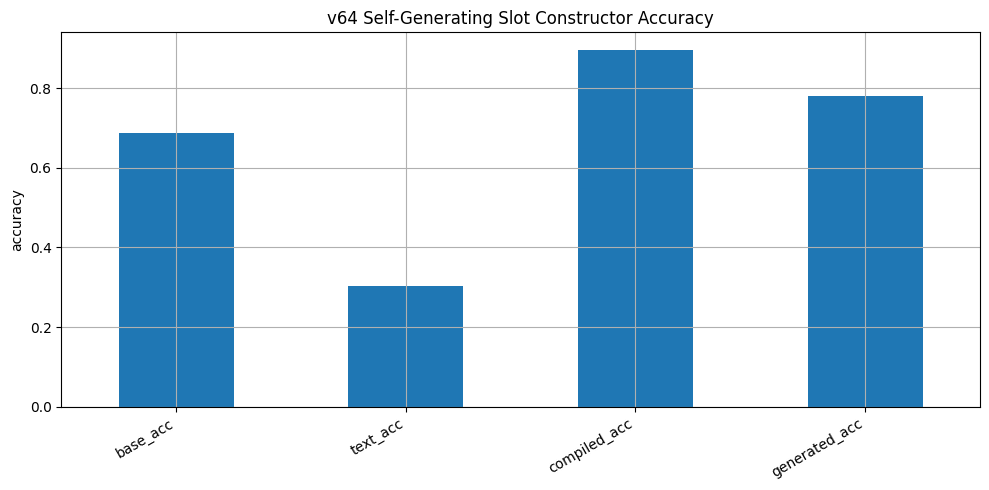

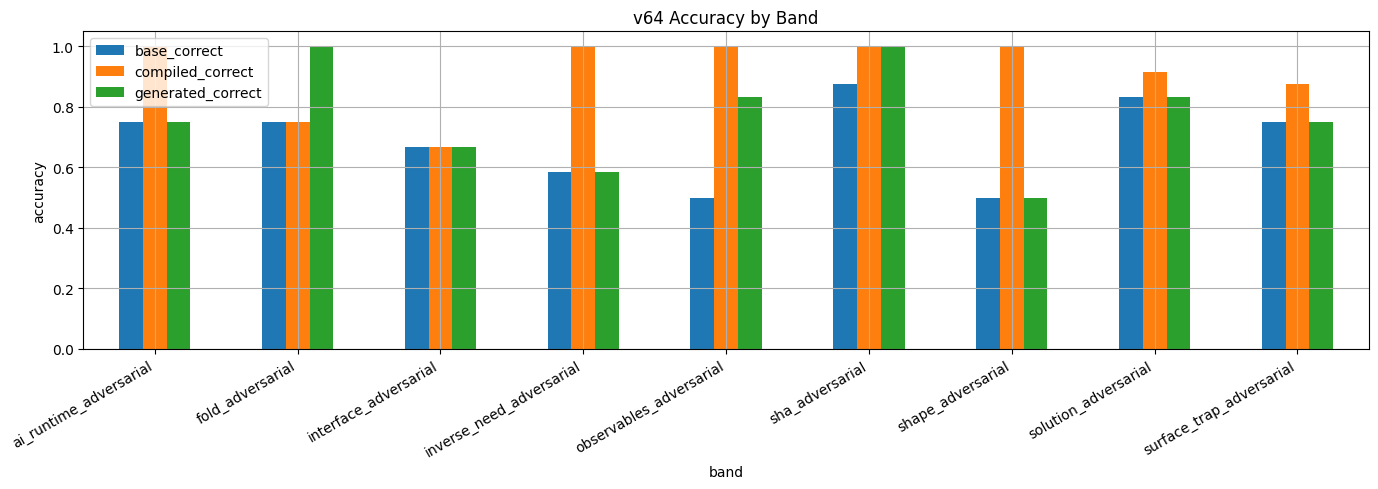

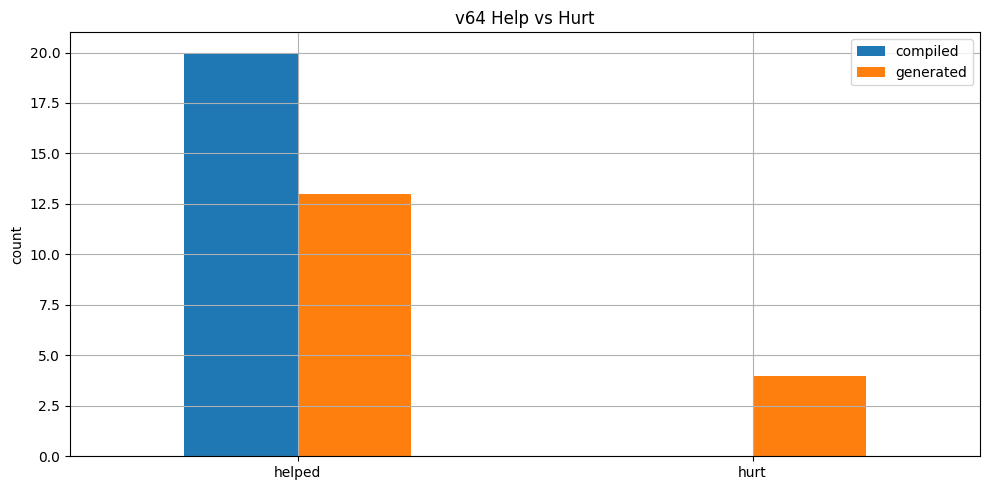

,wc_contract,wd_domain,wf_forbidden,ww_witness,support_min,margin_min,generated_acc,generated_gap_to_compiled,generated_gain_vs_base,generated_helped,generated_hurt,generated_omega_count,compiled_acc


In [13]:
# Plots

summary[["base_acc","text_acc","compiled_acc","generated_acc"]].T.plot(kind="bar",legend=False)
plt.title("v64 Self-Generating Slot Constructor Accuracy")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

by_band.set_index("band")[["base_correct","compiled_correct","generated_correct"]].plot(kind="bar", figsize=(14,5))
plt.title("v64 Accuracy by Band")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "compiled":[results_df.compiled_helped.sum(),results_df.compiled_hurt.sum()],
    "generated":[results_df.generated_helped.sum(),results_df.generated_hurt.sum()],
}, index=["helped","hurt"]).plot(kind="bar")
plt.title("v64 Help vs Hurt")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(ranked[ranked.generated_hurt==0].head(40)[["wc_contract","wd_domain","wf_forbidden","ww_witness","support_min","margin_min","generated_acc","generated_gap_to_compiled","generated_gain_vs_base","generated_helped","generated_hurt","generated_omega_count","compiled_acc"]])


In [14]:
# Contract inspection

for row_id in interesting["id"].head(30):
    print("="*100)
    print("CASE:", row_id)
    display(results_df[results_df.id==row_id][["id","base_id","band","gold_choice","choice_source_ids","base_choice","base_correct","compiled_choice","compiled_correct","generated_choice","generated_correct","generated_reason","generated_omega","family_class","domain_carrier","forbidden_neighbor_carrier","boundary_conditions","preserved_function","failure_modes","witness_readout"]])
    display(final_tables[row_id].sort_values("generated_contract_score", ascending=False))


CASE: adv_coupler_01__rot0


,id,base_id,band,gold_choice,choice_source_ids,base_choice,base_correct,compiled_choice,compiled_correct,generated_choice,generated_correct,generated_reason,generated_omega,family_class,domain_carrier,forbidden_neighbor_carrier,boundary_conditions,preserved_function,failure_modes,witness_readout
0,adv_coupler_01__rot0,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_coupler_01|adv_loose_01|adv_api_01|adv_llm_01,complexity internalized below a stable interface,0,tight O-rings seated concentrically around the...,1,tight O-rings seated concentrically around the...,1,generated_contract_safe,0,tight fit assembly,spinning rubber coupler | vacuum pump shaft | ...,compression fitting | rotational alignment | s...,safe operation without damage | efficient coup...,transmitting rotational motion,incomplete radial compression leading to misal...,the coupler remains centered and rotates smoot...


,choice_idx,choice,choice_source_id,pos,neg_avoid,domain,forbidden,witness,full_contract,base_score,text_score,generated_contract_score,generated_evidence_score
0,0,tight O-rings seated concentrically around the...,adv_coupler_01,1.059385,-0.580473,1.463776,0.527326,1.425716,1.020073,-23.843750,-2.117188,1.037990,1.220672
3,3,an internal indexed fold-state emits a token a...,adv_llm_01,-0.942108,0.618680,-0.635244,-0.526364,-0.866622,-0.915934,-26.156250,-3.291016,-0.225345,-0.508206
1,1,loose coupling with enough fit to function,adv_loose_01,0.933886,-0.715363,0.111563,0.571737,0.284163,0.974448,-25.718750,-3.615234,-0.265127,-0.627608
2,2,complexity internalized below a stable interface,adv_api_01,-1.051162,0.677157,-0.940095,-0.572699,-0.843256,-1.078588,-17.765625,-3.048828,-0.547518,-0.084858


CASE: adv_coupler_01__rot1


,id,base_id,band,gold_choice,choice_source_ids,base_choice,base_correct,compiled_choice,compiled_correct,generated_choice,generated_correct,generated_reason,generated_omega,family_class,domain_carrier,forbidden_neighbor_carrier,boundary_conditions,preserved_function,failure_modes,witness_readout
1,adv_coupler_01__rot1,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,adv_loose_01|adv_api_01|adv_llm_01|adv_coupler_01,complexity internalized below a stable interface,0,tight O-rings seated concentrically around the...,1,tight O-rings seated concentrically around the...,1,generated_contract_safe,0,tight fit assembly,spinning rubber coupler | vacuum pump shaft | ...,compression fitting | rotational alignment | s...,safe operation without damage | efficient coup...,transmitting rotational motion,incomplete radial compression leading to misal...,the coupler remains centered and rotates smoot...


...

,id,base_id,band,gold_choice,choice_source_ids,base_choice,base_correct,compiled_choice,compiled_correct,generated_choice,generated_correct,generated_reason,generated_omega,family_class,domain_carrier,forbidden_neighbor_carrier,boundary_conditions,preserved_function,failure_modes,witness_readout
57,adv_surface_02__rot1,adv_surface_02,surface_trap_adversarial,surface citation without operational collapse,adv_surface_01|adv_coupler_01|adv_commit_01|ad...,surface citation without operational collapse,1,surface citation without operational collapse,1,surface citation without operational collapse,1,omega_generated_contract_no_safe_collapse_keep...,1,algebraic transformation,mathematics | geometry | topology,algorithm | programming | data structure,theorems involving transformations preserving ...,the preservation of shape boundaries and prope...,non-injective functions failing to preserve di...,a geometric figure showing how a shape's bound...


,choice_idx,choice,choice_source_id,pos,neg_avoid,domain,forbidden,witness,full_contract,base_score,text_score,generated_contract_score,generated_evidence_score
1,1,tight O-rings seated concentrically around the...,adv_coupler_01,0.187413,0.373207,0.847001,-0.140854,0.203854,0.188285,-24.515625,-2.460938,1.954891,0.728042
3,3,surface citation without operational collapse,adv_surface_02,0.454638,-0.121839,0.104832,0.235035,0.762953,0.460164,-18.265625,-6.039062,0.383641,0.135185
0,0,reject it because noun/vocabulary match is not...,adv_surface_01,-1.109082,0.741575,-0.356319,-0.798916,-1.142565,-1.190987,-19.890625,-2.595703,-0.511713,0.117945
2,2,"stored possibility, realizable transition, obs...",adv_commit_01,0.467031,-0.992944,-0.595513,0.704735,0.175757,0.542538,-25.093750,-3.521484,-1.826818,-0.981172


CASE: adv_surface_02__rot2


,id,base_id,band,gold_choice,choice_source_ids,base_choice,base_correct,compiled_choice,compiled_correct,generated_choice,generated_correct,generated_reason,generated_omega,family_class,domain_carrier,forbidden_neighbor_carrier,boundary_conditions,preserved_function,failure_modes,witness_readout
58,adv_surface_02__rot2,adv_surface_02,surface_trap_adversarial,surface citation without operational collapse,adv_coupler_01|adv_commit_01|adv_surface_02|ad...,surface citation without operational collapse,1,surface citation without operational collapse,1,surface citation without operational collapse,1,omega_generated_contract_no_safe_collapse_keep...,1,algebraic transformation,mathematics | geometry | topology,algorithm | programming | data structure,theorems involving transformations preserving ...,the preservation of shape boundaries and prope...,non-injective functions failing to preserve di...,a geometric figure showing how a shape's bound...


,choice_idx,choice,choice_source_id,pos,neg_avoid,domain,forbidden,witness,full_contract,base_score,text_score,generated_contract_score,generated_evidence_score
0,0,tight O-rings seated concentrically around the...,adv_coupler_01,0.187413,0.373207,0.847001,-0.140854,0.203854,0.188285,-27.734375,-2.369141,1.954890,0.638092
2,2,surface citation without operational collapse,adv_surface_02,0.454638,-0.121839,0.104832,0.235035,0.762953,0.460164,-18.421875,-5.714844,0.383641,0.087569
3,3,reject it because noun/vocabulary match is not...,adv_surface_01,-1.109082,0.741575,-0.356319,-0.798916,-1.142565,-1.190987,-19.140625,-2.474609,-0.511713,0.165904
1,1,"stored possibility, realizable transition, obs...",adv_commit_01,0.467031,-0.992944,-0.595513,0.704735,0.175757,0.542538,-25.781250,-3.298828,-1.826818,-0.891565


## v64 Readout

v64 separates three states:

$$
\Psi_1:
\text{generated contract matches compiled-slot performance with zero hurt}
$$

$$
\Psi_2:
\text{generated contract improves base but remains below compiled baseline}
$$

$$
\Omega:
\text{generated contract fails to separate domain carrier / forbidden neighbor carrier}
$$

The central diagnostic is:

$$
\Delta_{\text{constructor}}
=
\text{generated\_acc}
-
\text{compiled\_acc}
$$

Training corpus export:

```text
generated_contracts.csv
results.csv
interesting_cases.csv
branches_*.csv
```

This is the transition:

$$
\boxed{
\text{compile the missing-shape contract first; answer second}
}
$$
